<a href="https://colab.research.google.com/github/DeisyUdec/1-clase-de-prueba-Deep-Learning/blob/main/week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#semana 4
#aplicación del metodo de regularidad

In [1]:
# importar  librerias
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split

In [2]:
#creación de varibles
np.random.seed(0)
X = np.random.randn(100, 20)
y = (np.sum(X, axis=1) > 0).astype(int)

In [4]:
#se define el porcentaje de entrenamiento y validación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [6]:
#se crea el método de modelo sin regularización
def modelo_sin_regularizacion():
  model = keras.Sequential([ layers.Dense(64, activation='relu', input_shape=(20,)),
                             layers.Dense(32, activation='relu'),        layers.Dense(1, activation='sigmoid')
                               ])
  return model

In [7]:
#se crea el método de modelo con regularización

def modelo_con_regularizacion():
  model = keras.Sequential([layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01),
                     input_shape=(20,)),
                      layers.Dropout(0.5),
                              layers.Dense(32, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
                                    layers.Dense(32, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
                                    layers.Dropout(0.5),
                             layers.Dense(1, activation='sigmoid')
                              ])
  return model


In [8]:
#compilacion de los métodos
model1 = modelo_sin_regularizacion()
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model2 = modelo_con_regularizacion()
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
#Entrenamiento
history1 = model1.fit(X_train, y_train, epochs=40, validation_data=(X_test, y_test), verbose=0)
history2 = model2.fit(X_train, y_train, epochs=40, validation_data=(X_test, y_test), verbose=0)


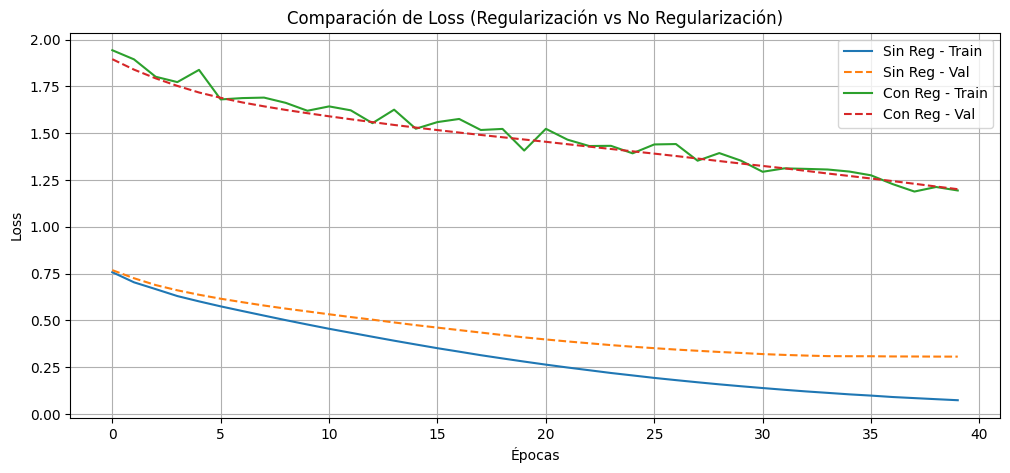

In [11]:
#Creación de graficas
plt.figure(figsize=(12,5))
plt.plot(history1.history['loss'], label='Sin Reg - Train')
plt.plot(history1.history['val_loss'], '--', label='Sin Reg - Val')
plt.plot(history2.history['loss'], label='Con Reg - Train')
plt.plot(history2.history['val_loss'], '--', label='Con Reg - Val')
plt.title("Comparación de Loss (Regularización vs No Regularización)")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()